# UNSW-NB15 — Task 2: Graph Construction (host-level train/test graphs) — Kaggle version
Group 5 · CSE475 · Track 1 (GNN)

This notebook takes Person 1's Task 2 outputs (`train_processed`, `test_processed`,
`side_train`, `side_test`) and turns them into **host-level graphs** ready for Person 4
to load into a GNN. Nodes are hosts (IP addresses); two separate edge sets are built per
split:

- **Main graph — temporal host-transition edges.** For each host, its flows (as either
  src or dst) are lined up in time order. Two flows that pass through the same host
  within a short time window get connected — specifically, the *other* endpoints of those
  two flows are linked — capturing "traffic arrived from X, then shortly after left toward
  Y" chains through that host. Directed, time-aware.
- **Comparison graph — plain contact edges.** Same hosts, but an edge just means "these
  two hosts exchanged at least one flow," with no time ordering. This is the simpler
  baseline graph kept separately for later comparison.

**Pipeline order:** load Person 1's outputs → re-attach host identity to the cleaned flow
features (join on `flow_id`) → melt into a per-host event log → per-host summary features
(node table) → temporal host-transition edges (main graph) → contact edges (comparison
graph) → leakage checks (train edges only reference train flow_ids, and vice versa) →
node-index mapping for GNN loading → save outputs → final stats summary.

**The one rule that matters most, same as Task 2:** train and test are built from
`train_processed`/`side_train` and `test_processed`/`side_test` respectively, and never
combined — every function below runs once per split, on that split's data only.

## 0. Setup
Imports + locate Person 1's `task2_outputs` folder.

**Kaggle workflow:** Person 1 should upload their `task2_outputs/` folder (the six
`.pkl`/`.csv` files) as a Kaggle Dataset - either "New Dataset" from the output of their
Task 2 kernel, or a manual file upload - then you add it to *this* kernel via
**Add Input → your dataset** in the right sidebar. It will show up read-only under
`/kaggle/input/<dataset-slug>/...`; auto-detect below finds it from there. Edit
`TASK2_DIR` directly if it doesn't.

In [1]:
import os, glob, pickle, warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

# Time window for the main (temporal) graph - two flows through the same host within this
# many seconds get chained into an edge. 5 minutes is a starting point; tighten/loosen and
# re-run if the resulting graph is too dense/sparse for the report.
TEMPORAL_WINDOW_SECONDS = 5 * 60

In [2]:
# EDIT THIS if auto-detect below doesn't find your files - point it straight at the
# Kaggle input folder Person 1's task2_outputs dataset was added under, e.g.
# '/kaggle/input/group05-task2-outputs'.
TASK2_DIR = '/kaggle/input'

def find_task2_dir(start_dirs, filename='train_processed.pkl'):
    """Search a few likely locations for Person 1's Task 2 outputs and return the folder."""
    for start in start_dirs:
        if not os.path.isdir(start):
            continue
        hits = glob.glob(os.path.join(start, '**', filename), recursive=True)
        if hits:
            return os.path.dirname(hits[0])
    return None

# Kaggle inputs are read-only under /kaggle/input/<dataset-slug>/...; /kaggle/working and
# the current working directory are checked too in case the pickles were generated earlier
# in this same session instead of added as a dataset.
SEARCH_DIRS = [TASK2_DIR, '/kaggle/input', '/kaggle/working', os.getcwd()]
found = find_task2_dir(SEARCH_DIRS)

if found:
    TASK2_DIR = found
    print("Using TASK2_DIR:", TASK2_DIR)
    print(os.listdir(TASK2_DIR))
else:
    print("Could not find train_processed.pkl in any of:")
    for d in SEARCH_DIRS:
        print("  -", d, "(exists)" if os.path.isdir(d) else "(does not exist)")
    if os.path.isdir('/kaggle/input'):
        print("\nWhat's actually under /kaggle/input:", os.listdir('/kaggle/input'))
    raise FileNotFoundError(
        "Add Person 1's task2_outputs as a Kaggle Dataset via 'Add Input' in the right "
        "sidebar (or generate it earlier in this same session), then point TASK2_DIR at "
        "the exact folder above and re-run this cell."
    )

Using TASK2_DIR: /kaggle/input/datasets/shahiismyname/unsw-nb15-preprocessed-dataset
['train_processed.csv', 'side_train.pkl', 'train_processed.pkl', 'side_train.csv', 'fitted_transforms.pkl', 'side_test.csv', 'test_processed.pkl', 'side_test.pkl', 'test_processed.csv']


## 1. Load Person 1's outputs
`*_processed` are the model-input frames (features only, no IP/port/time). `side_*` are
the matching IP/port/time slices, linked back by `flow_id`. Both are needed here:
`side_*` gives us the host identity that Task 2 deliberately stripped out of the model
frames, and `*_processed` gives us the cleaned numeric/categorical flow features to
summarize per host.

In [3]:
def load_pickle(name, folder=TASK2_DIR):
    with open(os.path.join(folder, f'{name}.pkl'), 'rb') as f:
        return pickle.load(f)

train_processed = load_pickle('train_processed')
test_processed = load_pickle('test_processed')
side_train = load_pickle('side_train')
side_test = load_pickle('side_test')

print("train_processed:", train_processed.shape, "  side_train:", side_train.shape)
print("test_processed: ", test_processed.shape, "  side_test: ", side_test.shape)

# Belt-and-suspenders: side_* and *_processed should carry exactly the same flow_ids per
# split (they're two views of the same rows, split apart in Task 2 step 5). If they don't
# match, the join in the next step would silently drop or duplicate flows.
assert set(train_processed['flow_id']) == set(side_train['flow_id']), \
    "train_processed / side_train flow_id mismatch"
assert set(test_processed['flow_id']) == set(side_test['flow_id']), \
    "test_processed / side_test flow_id mismatch"
print("flow_id alignment OK for both splits")

train_processed: (1647532, 32)   side_train: (1647532, 7)
test_processed:  (411883, 32)   side_test:  (411883, 7)
flow_id alignment OK for both splits


In [4]:
def load_optional_pickle(name, folder=TASK2_DIR):
    """Load {name}.pkl if it exists; return None if it doesn't (no error either way)."""
    path = os.path.join(folder, f'{name}.pkl')
    if not os.path.isfile(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

# Optional: unscaled dur/sbytes/dbytes/Spkts, keyed by flow_id, if Person 1 exports them -
# see the note below. Expected columns: flow_id, dur, sbytes, dbytes, Spkts.
train_raw_numeric = load_optional_pickle('train_raw_numeric')
test_raw_numeric = load_optional_pickle('test_raw_numeric')
USE_RAW_NUMERIC = train_raw_numeric is not None and test_raw_numeric is not None

if USE_RAW_NUMERIC:
    print("Found train_raw_numeric.pkl / test_raw_numeric.pkl - node/edge duration & byte "
          "features below will use these unscaled values, so report stats come out in real "
          "seconds/bytes instead of z-score units.")
else:
    print("No train_raw_numeric.pkl / test_raw_numeric.pkl found - falling back to the "
          "StandardScaler-scaled dur/sbytes/dbytes/Spkts already in train_processed/"
          "test_processed (z-score units, not literal seconds/bytes - see the note below). "
          "Ask Person 1 to export flow_id + unscaled dur/sbytes/dbytes/Spkts as "
          "train_raw_numeric.pkl / test_raw_numeric.pkl if you want interpretable numbers "
          "in the report's graph-stats section instead.")

No train_raw_numeric.pkl / test_raw_numeric.pkl found - falling back to the StandardScaler-scaled dur/sbytes/dbytes/Spkts already in train_processed/test_processed (z-score units, not literal seconds/bytes - see the note below). Ask Person 1 to export flow_id + unscaled dur/sbytes/dbytes/Spkts as train_raw_numeric.pkl / test_raw_numeric.pkl if you want interpretable numbers in the report's graph-stats section instead.


## 2. Re-attach host identity to the cleaned flow features
Join each split's `*_processed` frame back to its `side_*` frame on `flow_id`. The result
has one row per flow, with both the cleaned/scaled/encoded features *and* `srcip`/`dstip`/
`Stime` back in one place - everything graph construction needs, still split-separated.

In [5]:
def merge_processed_with_side(processed_df, side_df):
    """Inner-join on flow_id; every row must survive 1:1, or something upstream misaligned."""
    merged = processed_df.merge(side_df, on='flow_id', how='inner', validate='one_to_one')
    assert len(merged) == len(processed_df) == len(side_df), \
        "merge changed row count - flow_id sets should have matched exactly"
    return merged

flows_train = merge_processed_with_side(train_processed, side_train)
flows_test = merge_processed_with_side(test_processed, side_test)

print("flows_train:", flows_train.shape, "  flows_test:", flows_test.shape)
flows_train.head()

flows_train: (1647532, 38)   flows_test: (411883, 38)


,proto,state,dur,sbytes,dbytes,sttl,dttl,service,Sload,Dload,Spkts,swin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Sintpkt,Dintpkt,tcprtt,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_src_ltm,ct_dst_sport_ltm,attack_cat,Label,flow_id,srcip,sport,dstip,dsport,Stime,Ltime
0,120.0,2.0,-0.052062,-0.086815,-0.248308,-0.225373,-0.157455,2.0,-0.105123,-0.530252,-0.473038,-1.552582,-1.060179,-1.060285,-0.388806,-0.745081,-0.260457,-0.099624,-0.121897,-0.249332,-0.064055,-0.051958,-0.143779,-0.22726,-0.137324,0,-0.503064,-0.329195,-0.135421,Normal,0,0,59.166.0.0,1390.0,149.171.126.6,53.0,1421927414,1421927414
1,120.0,2.0,-0.049191,-0.079771,-0.247485,-0.225373,-0.157455,0.0,-0.111342,-0.656888,-0.447486,-1.552582,-1.060179,-1.060285,0.013627,-0.762766,-0.260457,-0.099624,-0.121149,-0.246219,-0.061268,-0.046107,-0.143779,-0.22726,-0.137324,0,-0.703625,-0.329195,-0.135421,Normal,0,1,59.166.0.0,33661.0,149.171.126.9,1024.0,1421927414,1421927414
2,120.0,2.0,-0.052057,-0.086566,-0.248226,-0.225373,-0.157455,2.0,-0.104800,-0.527043,-0.473038,-1.552582,-1.060179,-1.060285,-0.346123,-0.724450,-0.260457,-0.099624,-0.121897,-0.249332,-0.064055,-0.051958,-0.143779,-0.22726,-0.137324,0,1.301987,-0.621064,-0.135421,Normal,0,2,59.166.0.6,1464.0,149.171.126.7,53.0,1421927414,1421927414
3,120.0,2.0,-0.052049,-0.086815,-0.248308,-0.225373,-0.157455,2.0,-0.106083,-0.547808,-0.473038,-1.552582,-1.060179,-1.060285,-0.388806,-0.745081,-0.260457,-0.099624,-0.121897,-0.249332,-0.064045,-0.051957,-0.143779,-0.22726,-0.137324,0,0.098620,-0.912933,-0.135421,Normal,0,3,59.166.0.5,3593.0,149.171.126.5,53.0,1421927414,1421927414
4,120.0,2.0,-0.052053,-0.086566,-0.248226,-0.225373,-0.157455,2.0,-0.105136,-0.533075,-0.473038,-1.552582,-1.060179,-1.060285,-0.346123,-0.724450,-0.260457,-0.099624,-0.121897,-0.249332,-0.064060,-0.051966,-0.143779,-0.22726,-0.137324,0,0.299181,-0.912933,-0.135421,Normal,0,4,59.166.0.3,49664.0,149.171.126.0,53.0,1421927414,1421927414


In [6]:
def use_raw_numeric_if_available(flows_df, raw_df, cols=('dur', 'sbytes', 'dbytes', 'Spkts')):
    """Swap in Person 1's unscaled dur/sbytes/dbytes/Spkts (if exported) so every node/edge
    feature computed from them downstream ends up in real seconds/bytes, not z-scores."""
    if raw_df is None:
        return flows_df
    missing = [c for c in cols if c not in raw_df.columns]
    assert not missing, f"raw-numeric file is missing expected columns: {missing}"
    raw = raw_df[['flow_id', *cols]].rename(columns={c: f'{c}_raw' for c in cols})
    merged = flows_df.merge(raw, on='flow_id', how='left', validate='one_to_one')
    raw_cols = [f'{c}_raw' for c in cols]
    assert merged[raw_cols].notna().all().all(), \
        "some flow_ids have no match in the raw-numeric file - check the two exports line up"
    for c in cols:
        merged[c] = merged[f'{c}_raw']
    return merged.drop(columns=raw_cols)

flows_train = use_raw_numeric_if_available(flows_train, train_raw_numeric)
flows_test = use_raw_numeric_if_available(flows_test, test_raw_numeric)
print("Using", "unscaled" if USE_RAW_NUMERIC else "scaled", "dur/sbytes/dbytes/Spkts from here on.")

Using scaled dur/sbytes/dbytes/Spkts from here on.


### A couple of things carried over from Task 2, worth flagging here
- **`dur`/`sbytes`/`dbytes` are scaled, unless a raw-numeric export was found above.** Person
  1's `StandardScaler` (fit on train only, Task 2 step 7e) transforms these to z-scores. If
  `train_raw_numeric.pkl`/`test_raw_numeric.pkl` were found in the previous step, the swap
  already happened and everything below is in real seconds/bytes; if not, "total bytes per
  host" etc. below is a sum of z-scores - fine as a *relative*, comparable feature across
  hosts in the same split, but don't read it as literal bytes in the report.
- **`Dpkts` doesn't exist anymore.** Task 2 step 7f dropped it as highly correlated with
  `dbytes`/`dloss`. So the packet-count side of the edge/node features below only has
  `Spkts` to work with - there's no destination-packet-count signal available, raw or scaled.

## 3. Melt flows into a per-host event log
Every flow touches two hosts. To compute per-host summaries and time-order a host's
activity, each flow contributes **two event rows** - one for `srcip`, one for `dstip` -
tagged with which role the host played and who the flow's other endpoint (`partner`) was.
`port` is fixed to `dsport` (the destination/service port) for both roles, since that's
what identifies *which service* the flow was about, regardless of which side a given host
was on.

If a flow's `srcip == dstip` (a host talking to itself), it contributes two identical-host
event rows - handled fine below, just noted as an edge case rather than filtered out.

In [7]:
def build_flow_host_events(flows_df):
    """One row per (flow, host-role) - the long format everything below groups on."""
    flows_df = flows_df.copy()
    flows_df['total_bytes'] = flows_df['sbytes'] + flows_df['dbytes']
    flows_df['total_pkts'] = flows_df['Spkts']  # Dpkts unavailable - see note above

    shared_cols = ['flow_id', 'Stime', 'proto', 'dsport', 'total_bytes', 'total_pkts',
                   'dur', 'Label', 'attack_cat']

    src_events = flows_df[['srcip', 'dstip'] + shared_cols].rename(
        columns={'srcip': 'host', 'dstip': 'partner'})
    src_events['role'] = 'src'

    dst_events = flows_df[['dstip', 'srcip'] + shared_cols].rename(
        columns={'dstip': 'host', 'srcip': 'partner'})
    dst_events['role'] = 'dst'

    events = pd.concat([src_events, dst_events], ignore_index=True)
    events = events.rename(columns={'Stime': 'time', 'dsport': 'port'})
    return events

events_train = build_flow_host_events(flows_train)
events_test = build_flow_host_events(flows_test)

print("events_train:", events_train.shape, " unique hosts:", events_train['host'].nunique())
print("events_test: ", events_test.shape, " unique hosts:", events_test['host'].nunique())
events_train.head()

events_train: (3295064, 12)  unique hosts: 49
events_test:  (823766, 12)  unique hosts: 47


,host,partner,flow_id,time,proto,port,total_bytes,total_pkts,dur,Label,attack_cat,role
0,59.166.0.0,149.171.126.6,0,1421927414,120.0,53.0,-0.335123,-0.473038,-0.052062,0,Normal,src
1,59.166.0.0,149.171.126.9,1,1421927414,120.0,1024.0,-0.327256,-0.447486,-0.049191,0,Normal,src
2,59.166.0.6,149.171.126.7,2,1421927414,120.0,53.0,-0.334792,-0.473038,-0.052057,0,Normal,src
3,59.166.0.5,149.171.126.5,3,1421927414,120.0,53.0,-0.335123,-0.473038,-0.052049,0,Normal,src
4,59.166.0.3,149.171.126.0,4,1421927414,120.0,53.0,-0.334792,-0.473038,-0.052053,0,Normal,src


## 4. Node table — per-host summary features
Grouped straight from the event log built above, so a host's features only ever come from
flows that actually appear in *this* split. The three requested features are
`avg_duration`, `total_bytes`, `num_connections`; `num_as_src` / `num_as_dst` /
`num_unique_partners` are cheap, useful extras from the same groupby (handy later for
telling apart "a host that mostly receives traffic" from "a host that mostly initiates
it," and for the isolated-host check in the final summary).

In [8]:
def build_node_features(events_df):
    """One row per host, aggregated over every event (src- or dst-role) it appears in."""
    g = events_df.groupby('host')
    nodes = g.agg(
        num_connections=('flow_id', 'size'),       # requested
        avg_duration=('dur', 'mean'),               # requested
        total_bytes=('total_bytes', 'sum'),         # requested
        num_as_src=('role', lambda s: (s == 'src').sum()),
        num_as_dst=('role', lambda s: (s == 'dst').sum()),
        num_unique_partners=('partner', 'nunique'),
    ).reset_index()
    return nodes

nodes_train = build_node_features(events_train)
nodes_test = build_node_features(events_test)

print("nodes_train:", nodes_train.shape)
print("nodes_test: ", nodes_test.shape)
nodes_train.sort_values('num_connections', ascending=False).head()

nodes_train: (49, 7)
nodes_test:  (47, 7)


,host,num_connections,avg_duration,total_bytes,num_as_src,num_as_dst,num_unique_partners
23,149.171.126.3,156500,-0.010778,2111.091764,290,156210,10
41,59.166.0.2,156467,-0.012302,1323.638807,156160,307,10
43,59.166.0.4,156377,-0.012827,277.851092,156083,294,10
22,149.171.126.2,156300,-0.012328,625.088798,278,156022,10
39,59.166.0.0,156289,-0.012126,939.591934,155973,316,10


## 5. Main graph — temporal host-transition edges
For each host, sort every flow that touches it (as src or dst) by time. For each
consecutive pair of flows A → B on that host, add a directed edge between the *other*
endpoint of A and the *other* endpoint of B, if B follows A within
`TEMPORAL_WINDOW_SECONDS`. Concretely: if host H saw a flow from P, then shortly after a
flow to Q, this adds an edge P → Q "via" H - traffic arriving at a host and something
leaving shortly after is exactly the kind of relay/pivot pattern worth exposing to a GNN
for this dataset.

Edge features, per the brief: `time_gap` (seconds between A and B), `proto_changed` /
`port_changed` (did the service look different between A and B), `byte_diff` / `pkt_diff`
(B's traffic volume minus A's). `flow_id_a`/`flow_id_b` are kept so an edge can always be
traced back to the two exact flows that produced it.

**Self-loops are kept, not filtered.** If P talks to H, then again shortly after (still
via H), the edge is P → P - a real repeated-contact burst, not a bug. `is_self_loop` flags
these so they're easy to include/exclude later without re-deriving the graph.

### Sanity-check the time window against the real data
With only 49 hosts averaging tens of thousands of flows each, `TEMPORAL_WINDOW_SECONDS`
could easily be way too loose (almost every consecutive pair chains → a near-complete
graph) or way too tight (almost nothing chains → a near-empty graph), and there's no way
to tell which without looking. This looks at the *unfiltered* gap between every host's
consecutive flows - no window applied yet - so the 5-minute default below can be picked
with actual numbers instead of a guess.

In [9]:
def time_gap_diagnostics(events_df):
    """Unfiltered consecutive-event time gaps per host - no window applied yet."""
    ev = events_df.sort_values(['host', 'time'], kind='mergesort').reset_index(drop=True)
    prev_time = ev.groupby('host')['time'].shift(1)
    gap = (ev['time'] - prev_time).dropna()
    pct = gap.quantile([0, .25, .5, .75, .90, .99, 1.0])
    pct.index = ['min', 'p25', 'median', 'p75', 'p90', 'p99', 'max']
    return gap, pct

gap_train, pct_train = time_gap_diagnostics(events_train)
gap_test, pct_test = time_gap_diagnostics(events_test)

print("Consecutive-flow time gaps per host, seconds (train):")
print(pct_train)
print("\nConsecutive-flow time gaps per host, seconds (test):")
print(pct_test)

for label, gap in [('train', gap_train), ('test', gap_test)]:
    share = (gap <= TEMPORAL_WINDOW_SECONDS).mean()
    print(f"\n{label}: {share:.1%} of consecutive pairs fall within the "
          f"{TEMPORAL_WINDOW_SECONDS}s window currently set above")
print("\nIf that share is near 0% or near 100%, adjust TEMPORAL_WINDOW_SECONDS in the "
      "Setup cell and re-run from there.")

Consecutive-flow time gaps per host, seconds (train):
min             0.0
p25             0.0
median          0.0
p75             1.0
p90             1.0
p99             6.0
max       2292501.0
Name: time, dtype: float64

Consecutive-flow time gaps per host, seconds (test):
min          0.0
p25          0.0
median       0.0
p75          1.0
p90          2.0
p99         10.0
max       7184.0
Name: time, dtype: float64

train: 100.0% of consecutive pairs fall within the 300s window currently set above

test: 100.0% of consecutive pairs fall within the 300s window currently set above

If that share is near 0% or near 100%, adjust TEMPORAL_WINDOW_SECONDS in the Setup cell and re-run from there.


In [10]:
def build_temporal_edges(events_df, window_seconds):
    """Directed host-transition edges, aggregated per (via_host, source_host, target_host)
    so repeated identical transitions collapse into one weighted edge instead of one row
    per individual instance."""
    ev = events_df.sort_values(['host', 'time', 'flow_id'], kind='mergesort').reset_index(drop=True)
    prev = ev.groupby('host').shift(1)

    time_gap = ev['time'] - prev['time']
    valid = time_gap.notna() & (time_gap > 0) & (time_gap <= window_seconds)

    raw = pd.DataFrame({
        'via_host': ev['host'],
        'source_host': prev['partner'],
        'target_host': ev['partner'],
        'time_gap': time_gap,
        'proto_changed': (ev['proto'] != prev['proto']).astype(int),
        'port_changed': (ev['port'] != prev['port']).astype(int),
        'byte_diff': ev['total_bytes'] - prev['total_bytes'],
        'pkt_diff': ev['total_pkts'] - prev['total_pkts'],
        'flow_id_a': prev['flow_id'],
        'flow_id_b': ev['flow_id'],
    })[valid].reset_index(drop=True)

    raw['flow_id_a'] = raw['flow_id_a'].astype(int)
    raw['flow_id_b'] = raw['flow_id_b'].astype(int)
    raw['is_self_loop'] = raw['source_host'] == raw['target_host']

    edges = raw.groupby(['via_host', 'source_host', 'target_host']).agg(
        transition_count=('time_gap', 'size'),
        time_gap=('time_gap', 'mean'),
        proto_changed=('proto_changed', 'mean'),   # now a rate, 0-1, not a single flag
        port_changed=('port_changed', 'mean'),     # same
        byte_diff=('byte_diff', 'mean'),
        pkt_diff=('pkt_diff', 'mean'),
        is_self_loop=('is_self_loop', 'first'),
    ).reset_index()

    return edges, raw   # raw kept only for the leakage check below


edges_temporal_train, raw_temporal_train = build_temporal_edges(events_train, TEMPORAL_WINDOW_SECONDS)
edges_temporal_test, raw_temporal_test = build_temporal_edges(events_test, TEMPORAL_WINDOW_SECONDS)

print(f"Temporal window: {TEMPORAL_WINDOW_SECONDS}s")
print("edges_temporal_train (aggregated):", edges_temporal_train.shape,
      " self-loops:", int(edges_temporal_train['is_self_loop'].sum()))
print("edges_temporal_test (aggregated): ", edges_temporal_test.shape,
      " self-loops:", int(edges_temporal_test['is_self_loop'].sum()))
edges_temporal_train.sort_values('transition_count', ascending=False).head()

Temporal window: 300s
edges_temporal_train (aggregated): (2678, 10)  self-loops: 302
edges_temporal_test (aggregated):  (2634, 10)  self-loops: 298


,via_host,source_host,target_host,transition_count,time_gap,proto_changed,port_changed,byte_diff,pkt_diff,is_self_loop
397,149.171.126.18,175.45.176.1,175.45.176.1,4924,1.523964,0.040414,0.062348,-0.014181,-0.007446,True
1430,175.45.176.1,149.171.126.18,149.171.126.18,3682,1.178436,0.042640,0.057577,-0.037311,-0.017071,True
408,149.171.126.18,175.45.176.3,175.45.176.3,3012,1.718792,0.061089,0.096614,-0.010838,-0.009374,True
293,149.171.126.12,175.45.176.0,175.45.176.0,2903,1.704788,0.039614,0.094730,-0.017932,-0.020191,True
1254,175.45.176.0,149.171.126.12,149.171.126.12,2120,1.236792,0.029245,0.071698,-0.021650,-0.026853,True


## 6. Comparison graph — plain contact edges
The simpler graph: same host nodes, one undirected edge per pair of hosts that exchanged
at least one flow, no time ordering. `(srcip, dstip)` is sorted per row first so `A↔B` and
`B↔A` flows collapse onto the same edge rather than being stored twice. `num_flows` is the
edge weight; `total_bytes`/`avg_duration` summarize that pair's traffic the same way the
node table does. Kept in entirely separate `edges_contact_*` variables/files from the
temporal graph throughout, per the brief.

In [11]:
def build_contact_edges(flows_df):
    """One undirected edge per unordered (host_a, host_b) pair with >=1 shared flow."""
    df = flows_df.copy()
    df['total_bytes'] = df['sbytes'] + df['dbytes']

    pair = np.sort(df[['srcip', 'dstip']].to_numpy(dtype=str), axis=1)
    df['source_host'] = pair[:, 0]
    df['target_host'] = pair[:, 1]

    edges = df.groupby(['source_host', 'target_host']).agg(
        num_flows=('flow_id', 'size'),
        total_bytes=('total_bytes', 'sum'),
        avg_duration=('dur', 'mean'),
    ).reset_index()
    edges['is_self_loop'] = edges['source_host'] == edges['target_host']
    return edges

edges_contact_train = build_contact_edges(flows_train)
edges_contact_test = build_contact_edges(flows_test)

print("edges_contact_train:", edges_contact_train.shape)
print("edges_contact_test: ", edges_contact_test.shape)
edges_contact_train.sort_values('num_flows', ascending=False).head()

edges_contact_train: (169, 6)
edges_contact_test:  (161, 6)


,source_host,target_host,num_flows,total_bytes,avg_duration,is_self_loop
106,149.171.126.4,59.166.0.5,16259,155.297059,-0.010791,False
83,149.171.126.2,59.166.0.2,16154,-46.606034,-0.012577,False
96,149.171.126.3,59.166.0.5,16086,-25.437768,-0.011628,False
95,149.171.126.3,59.166.0.4,16039,-210.772548,-0.014534,False
102,149.171.126.4,59.166.0.1,16013,-144.456195,-0.015283,False


## 7. Leakage checks
Both graphs above are already built from one split's `events_df` at a time, so a mixed
edge shouldn't be possible - but that was also true of the dedup step in Task 2, and it
still got an explicit printed check rather than being assumed. Same approach here: every
`flow_id` referenced by a train edge must be a train flow_id, and likewise for test.

In [12]:
def leakage_check(edges, allowed_flow_ids, flow_id_cols, label):
    leaked = 0
    for c in flow_id_cols:
        if c in edges.columns:
            leaked += int((~edges[c].isin(allowed_flow_ids)).sum())
    status = "OK - no leakage" if leaked == 0 else f"LEAK: {leaked} bad references"
    print(f"{label}: {status}")
    return leaked

train_flow_ids = set(train_processed['flow_id'])
test_flow_ids = set(test_processed['flow_id'])

total_leaked = 0
total_leaked += leakage_check(raw_temporal_train, train_flow_ids,
                               ['flow_id_a', 'flow_id_b'], "temporal train edges (pre-aggregation)")
total_leaked += leakage_check(raw_temporal_test, test_flow_ids,
                               ['flow_id_a', 'flow_id_b'], "temporal test edges (pre-aggregation)")

assert total_leaked == 0, "train/test flow_ids are mixed somewhere above - stop and check"
print("\nNo cross-split leakage detected in either graph.")

temporal train edges (pre-aggregation): OK - no leakage
temporal test edges (pre-aggregation): OK - no leakage

No cross-split leakage detected in either graph.


## 8. Node-index mapping for Person 4
GNN loaders (PyG, DGL, ...) want contiguous integer node ids, not IP strings. Both graphs
for a split share the same node table (same hosts, same features) - the same
`host -> node_index` mapping is reused for the temporal edges and the contact edges below,
built separately per split so train and test stay two entirely separate graphs.

In [13]:
def add_node_index(nodes_df):
    nodes_df = nodes_df.sort_values('host').reset_index(drop=True)
    nodes_df.insert(0, 'node_index', np.arange(len(nodes_df)))
    return nodes_df

def map_edges_to_index(edges_df, host_to_index, host_cols):
    edges_df = edges_df.copy()
    for c in host_cols:
        edges_df[f'{c}_idx'] = edges_df[c].map(host_to_index)
        assert edges_df[f'{c}_idx'].notna().all(), f"unmapped host in column {c}"
        edges_df[f'{c}_idx'] = edges_df[f'{c}_idx'].astype(int)
    return edges_df

nodes_train = add_node_index(nodes_train)
nodes_test = add_node_index(nodes_test)

host_to_index_train = dict(zip(nodes_train['host'], nodes_train['node_index']))
host_to_index_test = dict(zip(nodes_test['host'], nodes_test['node_index']))

edges_temporal_train = map_edges_to_index(edges_temporal_train, host_to_index_train,
                                           ['source_host', 'target_host', 'via_host'])
edges_temporal_test = map_edges_to_index(edges_temporal_test, host_to_index_test,
                                          ['source_host', 'target_host', 'via_host'])
edges_contact_train = map_edges_to_index(edges_contact_train, host_to_index_train,
                                          ['source_host', 'target_host'])
edges_contact_test = map_edges_to_index(edges_contact_test, host_to_index_test,
                                         ['source_host', 'target_host'])

print("Node index assigned - e.g. train host_to_index sample:",
      dict(list(host_to_index_train.items())[:3]))

Node index assigned - e.g. train host_to_index sample: {'10.40.170.2': 0, '10.40.182.1': 1, '10.40.182.255': 2}


## 9. Save outputs
One node table per split (shared by both graphs) plus two edge tables per split (temporal,
contact) - six files total, each as both `.pkl` (exact dtypes) and `.csv` (easy to
eyeball), matching Task 2's save format so Person 4 can load either.

**Kaggle note:** only files under `/kaggle/working` are captured as this kernel's output/artifacts - anything saved outside it (e.g. `/kaggle/input`, which is read-only anyway, or `/content`) will vanish when the session ends. Once this cell runs, the six files show up under the kernel's Output tab and can be published as a new Kaggle Dataset for Person 4 to add as their own input.

In [14]:
OUT_DIR = '/kaggle/working/task2_outputs'  # only /kaggle/working persists as kernel output
os.makedirs(OUT_DIR, exist_ok=True)

def save_outputs(name, obj, out_dir=OUT_DIR):
    pkl_path = os.path.join(out_dir, f'{name}.pkl')
    with open(pkl_path, 'wb') as f:
        pickle.dump(obj, f)
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(os.path.join(out_dir, f'{name}.csv'), index=False)
    print("Saved:", pkl_path)

save_outputs('nodes_train', nodes_train)
save_outputs('nodes_test', nodes_test)
save_outputs('edges_temporal_train', edges_temporal_train)
save_outputs('edges_temporal_test', edges_temporal_test)
save_outputs('edges_contact_train', edges_contact_train)
save_outputs('edges_contact_test', edges_contact_test)

save_outputs('graph_build_config', {
    'temporal_window_seconds': TEMPORAL_WINDOW_SECONDS,
    'node_feature_cols': ['num_connections', 'avg_duration', 'total_bytes',
                           'num_as_src', 'num_as_dst', 'num_unique_partners'],
    'temporal_edge_feature_cols': ['transition_count', 'time_gap', 'proto_changed',
                                    'port_changed', 'byte_diff', 'pkt_diff'],
    'contact_edge_feature_cols': ['num_flows', 'total_bytes', 'avg_duration'],
})
print("\nAll outputs saved to:", OUT_DIR)

Saved: /kaggle/working/task2_outputs/nodes_train.pkl
Saved: /kaggle/working/task2_outputs/nodes_test.pkl
Saved: /kaggle/working/task2_outputs/edges_temporal_train.pkl
Saved: /kaggle/working/task2_outputs/edges_temporal_test.pkl
Saved: /kaggle/working/task2_outputs/edges_contact_train.pkl
Saved: /kaggle/working/task2_outputs/edges_contact_test.pkl
Saved: /kaggle/working/task2_outputs/graph_build_config.pkl

All outputs saved to: /kaggle/working/task2_outputs


## 10. Final summary
Basic stats for the report: node/edge counts, average connections per host, and any hosts
with zero connections - for both graphs, both splits. "Connections" here counts an edge
toward both endpoints it touches (so an isolated host has degree 0 in that graph).

The "hosts with no connections" check below also looks at the **full host universe**
(train ∪ test host IDs, from `side_train`/`side_test`) so it can flag a host that exists
in the dataset but simply has no flows falling inside this split's time range - this is
bookkeeping over host *identifiers* only, not a feature or an edge, so it doesn't
reintroduce any train/test leakage.

In [15]:
def graph_stats(nodes_df, edges_df, src_col='source_host', dst_col='target_host'):
    n_nodes = len(nodes_df)
    n_edges = len(edges_df)
    degree = pd.concat([edges_df[src_col], edges_df[dst_col]]).value_counts()
    degree = degree.reindex(nodes_df['host']).fillna(0)
    return {
        'n_nodes': n_nodes,
        'n_edges': n_edges,
        'avg_connections_per_host': round(degree.mean(), 3) if n_nodes else 0,
        'hosts_with_no_connections': degree[degree == 0].index.tolist(),
    }

ALL_HOSTS = pd.unique(pd.concat([
    side_train[['srcip', 'dstip']].stack(),
    side_test[['srcip', 'dstip']].stack(),
]))

print("=" * 60)
print("TASK 2 GRAPH CONSTRUCTION SUMMARY")
print("=" * 60)

print(f"\nTotal unique hosts across the whole dataset (train U test): {len(ALL_HOSTS)}")

for split_name, nodes_df, side_df in [('train', nodes_train, side_train),
                                       ('test', nodes_test, side_test)]:
    hosts_in_split = set(nodes_df['host'])
    absent = sorted(set(ALL_HOSTS) - hosts_in_split)
    print(f"\n--- {split_name} ---")
    print(f"Hosts active in this split: {len(hosts_in_split)} / {len(ALL_HOSTS)}")
    print(f"Hosts with zero flows in this split's time range: {absent if absent else '(none)'}")

for split_name, nodes_df, edges_temp, edges_cont in [
    ('train', nodes_train, edges_temporal_train, edges_contact_train),
    ('test', nodes_test, edges_temporal_test, edges_contact_test),
]:
    print(f"\n--- {split_name} - main (temporal) graph ---")
    print(graph_stats(nodes_df, edges_temp))
    print(f"--- {split_name} - comparison (contact) graph ---")
    print(graph_stats(nodes_df, edges_cont))

print(f"\nTemporal window used: {TEMPORAL_WINDOW_SECONDS}s")
print("Node feature columns:", ['num_connections', 'avg_duration', 'total_bytes',
                                 'num_as_src', 'num_as_dst', 'num_unique_partners'])

# Attack rate per split, straight from the flow-level Label - included here because Person 1
# flagged it as a real train/test difference from the time-based split (concentrated later),
# not a graph-construction artifact, and it's the first thing that'll explain why the two
# graphs' Label-related numbers don't match.
print("\nAttack rate (Label=1) by split, for context on the numbers above:")
print(f"  train: {flows_train['Label'].mean():.2%}")
print(f"  test:  {flows_test['Label'].mean():.2%}")

TASK 2 GRAPH CONSTRUCTION SUMMARY

Total unique hosts across the whole dataset (train U test): 49

--- train ---
Hosts active in this split: 49 / 49
Hosts with zero flows in this split's time range: (none)

--- test ---
Hosts active in this split: 47 / 49
Hosts with zero flows in this split's time range: ['127.0.0.1', '192.168.241.243']

--- train - main (temporal) graph ---
{'n_nodes': 49, 'n_edges': 2678, 'avg_connections_per_host': np.float64(109.306), 'hosts_with_no_connections': ['127.0.0.1']}
--- train - comparison (contact) graph ---
{'n_nodes': 49, 'n_edges': 169, 'avg_connections_per_host': np.float64(6.898), 'hosts_with_no_connections': []}

--- test - main (temporal) graph ---
{'n_nodes': 47, 'n_edges': 2634, 'avg_connections_per_host': np.float64(112.085), 'hosts_with_no_connections': []}
--- test - comparison (contact) graph ---
{'n_nodes': 47, 'n_edges': 161, 'avg_connections_per_host': np.float64(6.851), 'hosts_with_no_connections': []}

Temporal window used: 300s
Node f

## 11. Visualize the graphs (for the report)
Everything above builds the graphs as *data* (node/edge tables for the GNN) - this section
just draws them, for the report/slides.

The comparison (contact) graph is small enough to plot exactly as saved: at most
`49 choose 2` ≈ 1,176 possible host pairs. The temporal graph is a different story - with
only ~49 hosts carrying potentially millions of flows between them, a literal one-line-per-edge
plot would just be an unreadable smear. So **for this picture only**, repeated `source_host →
target_host` transitions are collapsed into one arrow, weighted by how many times that
transition occurred - the saved `edges_temporal_*` files themselves are untouched, still one
row per individual transition, exactly as before.

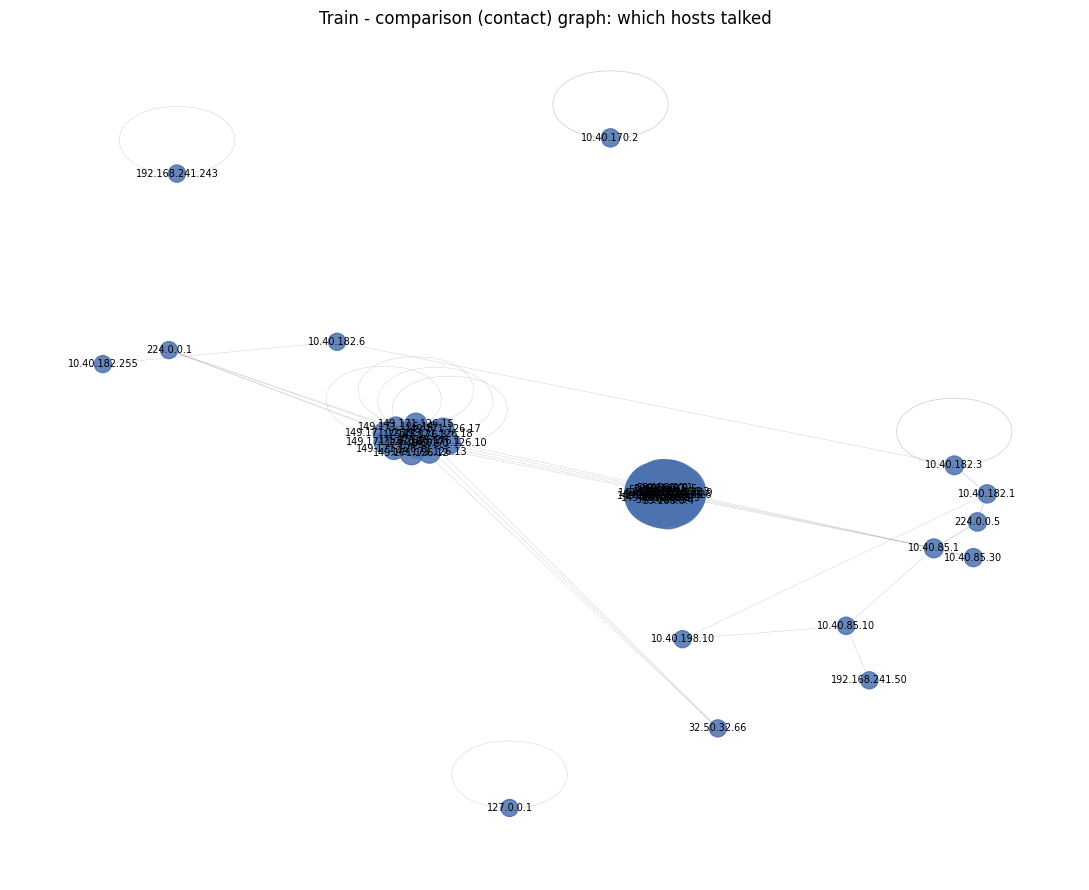

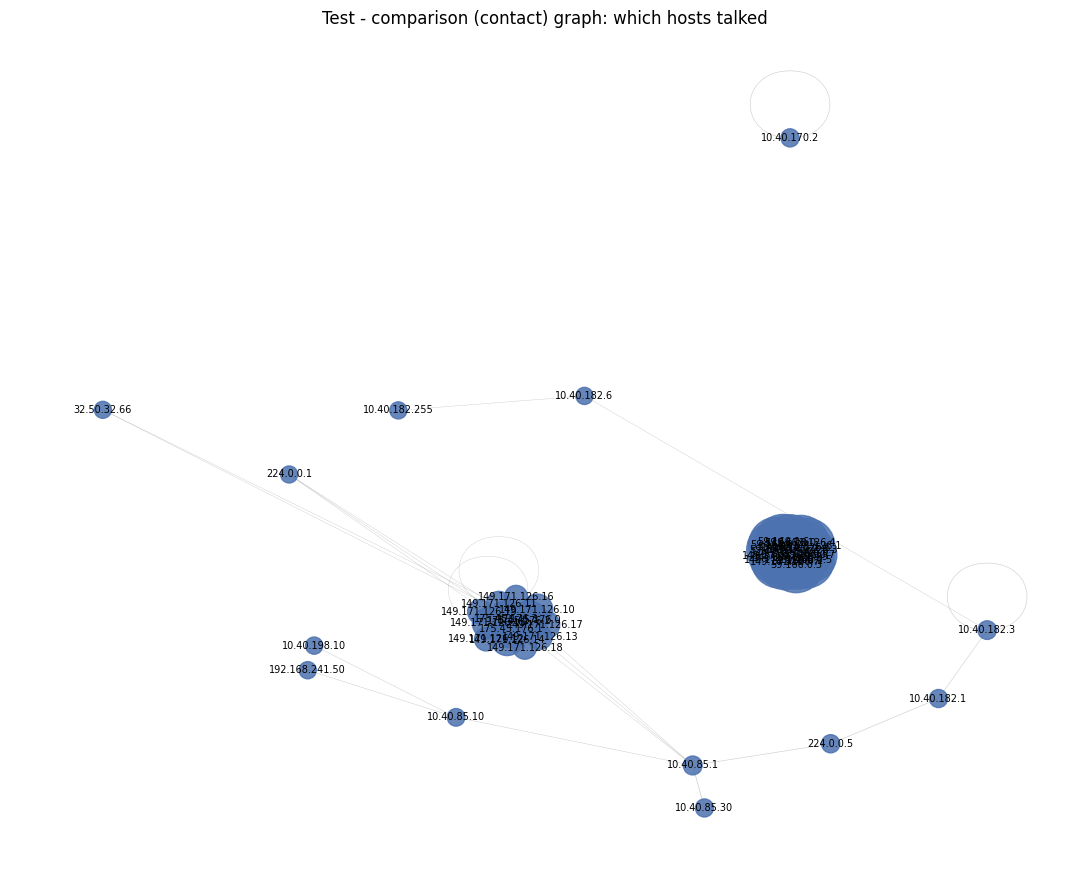

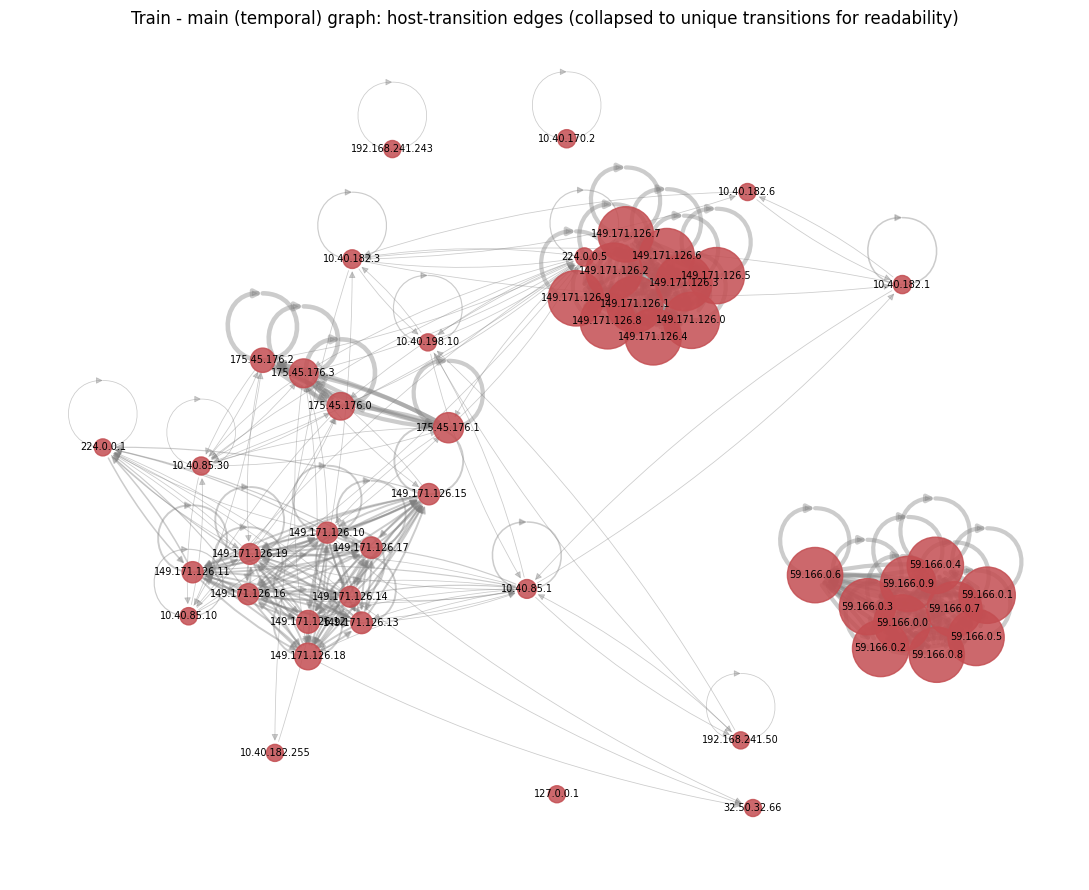

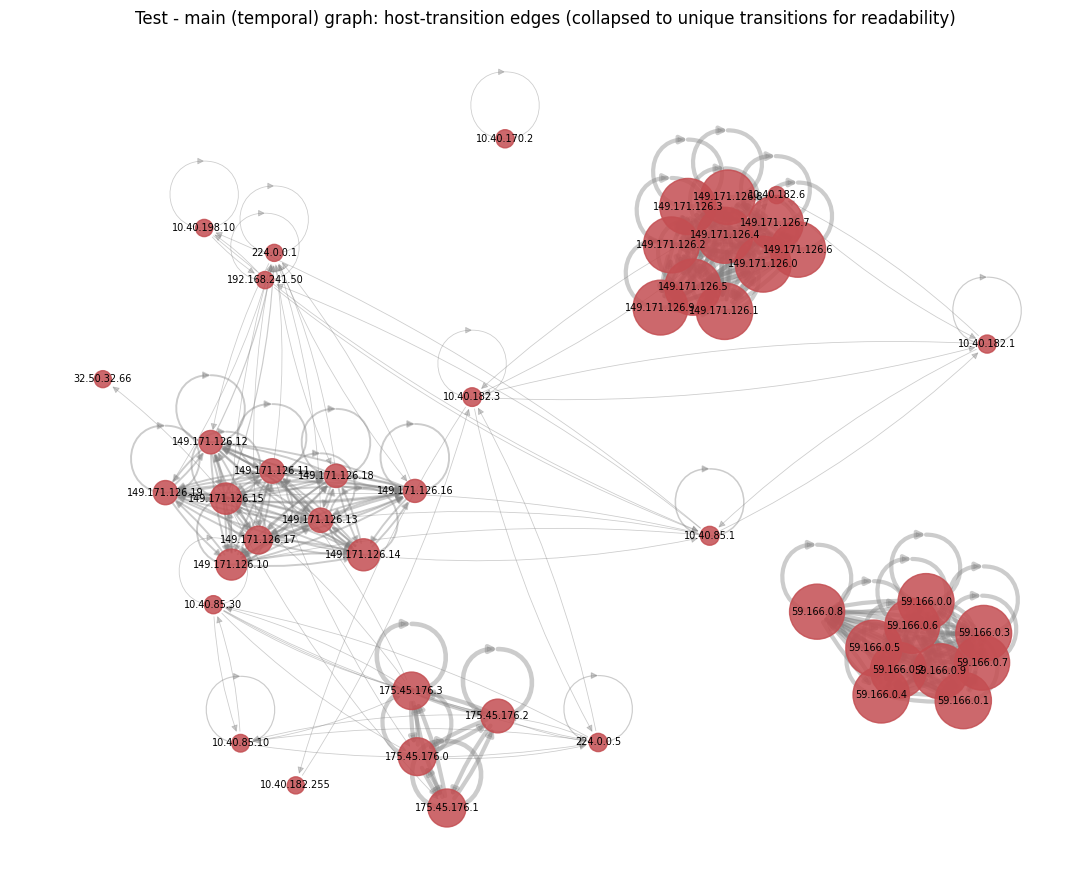

Saved 4 PNGs to /kaggle/working/task2_outputs - they'll show up in this kernel's Output tab.


In [16]:
def plot_contact_graph(nodes_df, edges_df, title, save_path=None):
    """Plots the contact graph as-is - small enough (<=49 hosts) to show every edge."""
    G = nx.Graph()
    for _, row in nodes_df.iterrows():
        G.add_node(row['host'], num_connections=row['num_connections'])
    for _, row in edges_df.iterrows():
        G.add_edge(row['source_host'], row['target_host'], weight=row['num_flows'])

    pos = nx.spring_layout(G, seed=42, k=1.2)
    conn_vals = np.array([G.nodes[n]['num_connections'] for n in G.nodes], dtype=float)
    conn_norm = (conn_vals - conn_vals.min()) / (conn_vals.max() - conn_vals.min() + 1e-9)
    node_sizes = 150 + 1500 * conn_norm
    max_w = max(nx.get_edge_attributes(G, 'weight').values(), default=1)
    edge_widths = [0.3 + 3 * (G[u][v]['weight'] / max_w) for u, v in G.edges]

    plt.figure(figsize=(11, 9))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=7)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_temporal_transitions(nodes_df, edges_temp_df, title, save_path=None):
    """Collapses repeated host-to-host transitions into one weighted arrow, for a readable
    summary plot only - the saved edge table stays one row per individual transition."""
    agg = (edges_temp_df.groupby(['source_host', 'target_host'])
           .size().reset_index(name='weight'))

    G = nx.DiGraph()
    for _, row in nodes_df.iterrows():
        G.add_node(row['host'], num_connections=row['num_connections'])
    for _, row in agg.iterrows():
        G.add_edge(row['source_host'], row['target_host'], weight=row['weight'])

    pos = nx.spring_layout(G, seed=42, k=1.2)
    conn_vals = np.array([G.nodes[n]['num_connections'] for n in G.nodes], dtype=float)
    conn_norm = (conn_vals - conn_vals.min()) / (conn_vals.max() - conn_vals.min() + 1e-9)
    node_sizes = 150 + 1500 * conn_norm
    max_w = max(nx.get_edge_attributes(G, 'weight').values(), default=1)
    edge_widths = [0.3 + 3 * (G[u][v]['weight'] / max_w) for u, v in G.edges]

    plt.figure(figsize=(11, 9))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#C44E52', alpha=0.85)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, edge_color='gray',
                            arrows=True, arrowsize=10, connectionstyle='arc3,rad=0.08')
    nx.draw_networkx_labels(G, pos, font_size=7)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


plot_contact_graph(nodes_train, edges_contact_train,
                    "Train - comparison (contact) graph: which hosts talked",
                    save_path=os.path.join(OUT_DIR, 'contact_graph_train.png'))
plot_contact_graph(nodes_test, edges_contact_test,
                    "Test - comparison (contact) graph: which hosts talked",
                    save_path=os.path.join(OUT_DIR, 'contact_graph_test.png'))
plot_temporal_transitions(nodes_train, edges_temporal_train,
                           "Train - main (temporal) graph: host-transition edges "
                           "(collapsed to unique transitions for readability)",
                           save_path=os.path.join(OUT_DIR, 'temporal_graph_train.png'))
plot_temporal_transitions(nodes_test, edges_temporal_test,
                           "Test - main (temporal) graph: host-transition edges "
                           "(collapsed to unique transitions for readability)",
                           save_path=os.path.join(OUT_DIR, 'temporal_graph_test.png'))
print("Saved 4 PNGs to", OUT_DIR, "- they'll show up in this kernel's Output tab.")